In [1]:
# ============================================================
# 2. Regime Clustering: Crisis vs Non-Crisis Detection
# Corrected for your dataset structure
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ------------------------------------------------------------
# 1. Load clean monthly panel
# ------------------------------------------------------------

df = pd.read_csv("data/clean_monthly_panel.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "permno"])

print(df.head())
print(df.columns)

     permno       ret  real_vol_monthly  real_vol_ann  real_vol_ann_lag1  \
0     10001 -0.018519          0.010798      0.037405                NaN   
331   10002  0.020408          0.004351      0.018035                NaN   
595   10003 -0.088235          0.049991      0.173174                NaN   
666   10007 -0.474885          0.077862      0.269721                NaN   
674   10009 -0.103449          0.036663      0.127005                NaN   

     real_vol_ann_lag2  real_vol_ann_lag3     mktcap     liquidity  \
0                  NaN                NaN  10156.125  4.070197e-07   
331                NaN                NaN   7343.750  2.993592e-10   
595                NaN                NaN  17003.500  1.284666e-06   
666                NaN                NaN  14806.250  1.201624e-07   
674                NaN                NaN   6116.500  1.289630e-05   

     mkt_vol_ann  high_vol_regime  n_days       date  ret_lag1  ret_lag3  \
0       0.108909            False      22 1990

In [2]:
# ------------------------------------------------------------
# 2. Build market-level monthly regime dataset
# ------------------------------------------------------------

market_monthly = (
    df.groupby("date")
    .agg(
        market_ret=("ret", "mean"),
        avg_stock_vol=("real_vol_ann", "mean"),
        median_stock_vol=("real_vol_ann", "median"),
        market_vol=("mkt_vol_ann", "first"),
        high_vol_regime=("high_vol_regime", "first"),
        n_stocks=("permno", "nunique")
    )
    .reset_index()
)

# Rolling realized market volatility based on equal-weighted market returns
market_monthly["rolling_market_vol_12m"] = (
    market_monthly["market_ret"]
    .rolling(12)
    .std()
    * np.sqrt(12)
)

# Rolling average absolute market return
market_monthly["rolling_abs_ret_12m"] = (
    market_monthly["market_ret"]
    .abs()
    .rolling(12)
    .mean()
)

# Market drawdown
market_monthly["cum_market"] = (1 + market_monthly["market_ret"]).cumprod()
market_monthly["running_max"] = market_monthly["cum_market"].cummax()
market_monthly["drawdown"] = (
    market_monthly["cum_market"] / market_monthly["running_max"] - 1
)

market_monthly = market_monthly.dropna().reset_index(drop=True)

market_monthly.head()

,date,market_ret,avg_stock_vol,median_stock_vol,market_vol,high_vol_regime,n_stocks,rolling_market_vol_12m,rolling_abs_ret_12m,cum_market,running_max,drawdown
0,1990-12-31,0.020668,0.134581,0.108306,0.073878,False,4510,0.189559,0.046196,0.832773,1.024522,-0.187160
1,1991-01-31,0.090796,0.140279,0.117591,0.139088,False,4470,0.208320,0.048730,0.908385,1.024522,-0.113358
2,1991-02-28,0.126787,0.143106,0.119220,0.097569,False,4536,0.244264,0.057461,1.023556,1.024522,-0.000943
3,1991-03-31,0.078193,0.130852,0.109438,0.076152,False,4642,0.253623,0.061440,1.103591,1.103591,0.000000
4,1991-04-30,0.029571,0.128068,0.106790,0.076170,False,4721,0.250883,0.061817,1.136226,1.136226,0.000000


In [3]:
# ------------------------------------------------------------
# 3. Choose regime features
# ------------------------------------------------------------

regime_features = [
    "market_vol",
    "avg_stock_vol",
    "rolling_market_vol_12m",
    "rolling_abs_ret_12m",
    "drawdown"
]

X = market_monthly[regime_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# ------------------------------------------------------------
# 4. K-means clustering: k = 2 crisis / non-crisis
# ------------------------------------------------------------

kmeans = KMeans(n_clusters=2, random_state=42, n_init=50)
market_monthly["regime_cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = (
    market_monthly
    .groupby("regime_cluster")[regime_features + ["market_ret"]]
    .mean()
)

print(cluster_summary)

# Crisis cluster: high market volatility and/or worse drawdowns
crisis_cluster = cluster_summary["market_vol"].idxmax()

market_monthly["crisis_regime"] = (
    market_monthly["regime_cluster"] == crisis_cluster
).astype(int)

market_monthly[
    ["date", "market_ret", "market_vol", "drawdown", "crisis_regime"]
].head()

                market_vol  avg_stock_vol  rolling_market_vol_12m  \
regime_cluster                                                      
0                 0.115919       0.101365                0.150905   
1                 0.248826       0.141558                0.269433   

                rolling_abs_ret_12m  drawdown  market_ret  
regime_cluster                                             
0                          0.038489 -0.033215    0.015548  
1                          0.063087 -0.168100    0.009719  


,date,market_ret,market_vol,drawdown,crisis_regime
0,1990-12-31,0.020668,0.073878,-0.187160,0
1,1991-01-31,0.090796,0.139088,-0.113358,1
2,1991-02-28,0.126787,0.097569,-0.000943,0
3,1991-03-31,0.078193,0.076152,0.000000,0
4,1991-04-30,0.029571,0.076170,0.000000,0


In [5]:
# ------------------------------------------------------------
# 5. Evaluate clusters
# ------------------------------------------------------------

sil_score = silhouette_score(X_scaled, market_monthly["regime_cluster"])

print(f"Silhouette score: {sil_score:.3f}")
print()
print("Regime counts:")
print(market_monthly["crisis_regime"].value_counts())

print()
print("Average characteristics by regime:")
print(
    market_monthly
    .groupby("crisis_regime")[regime_features + ["market_ret"]]
    .mean()
)

Silhouette score: 0.437

Regime counts:
crisis_regime
0    301
1     96
Name: count, dtype: int64

Average characteristics by regime:
               market_vol  avg_stock_vol  rolling_market_vol_12m  \
crisis_regime                                                      
0                0.115919       0.101365                0.150905   
1                0.248826       0.141558                0.269433   

               rolling_abs_ret_12m  drawdown  market_ret  
crisis_regime                                             
0                         0.038489 -0.033215    0.015548  
1                         0.063087 -0.168100    0.009719  


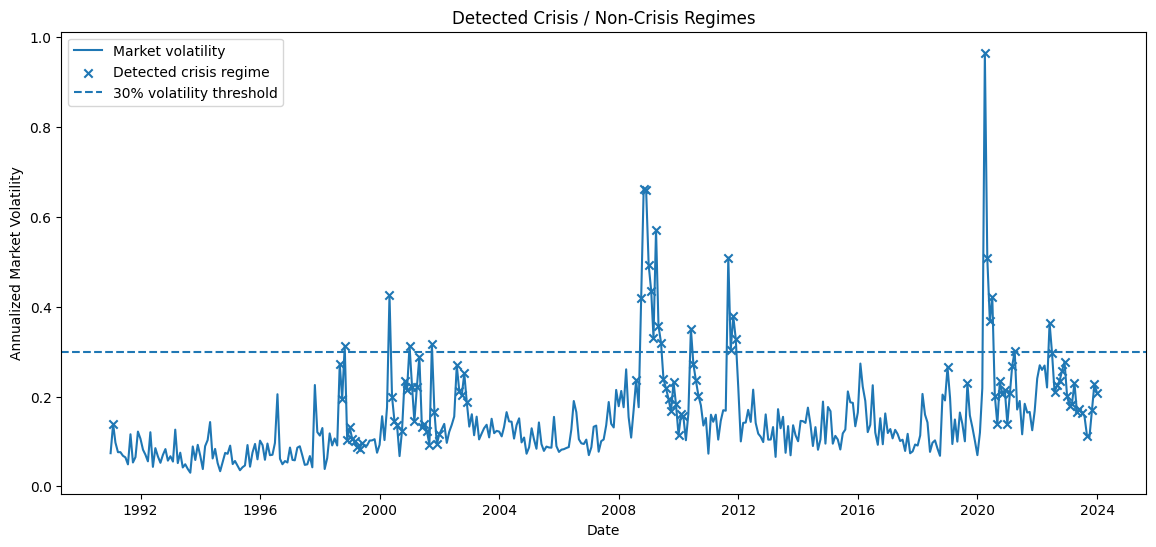

In [6]:
# ------------------------------------------------------------
# 6. Plot detected regimes
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    market_monthly["date"],
    market_monthly["market_vol"],
    label="Market volatility"
)

plt.scatter(
    market_monthly.loc[market_monthly["crisis_regime"] == 1, "date"],
    market_monthly.loc[market_monthly["crisis_regime"] == 1, "market_vol"],
    label="Detected crisis regime",
    marker="x"
)

plt.axhline(0.30, linestyle="--", label="30% volatility threshold")

plt.title("Detected Crisis / Non-Crisis Regimes")
plt.xlabel("Date")
plt.ylabel("Annualized Market Volatility")
plt.legend()
plt.show()

In [7]:
# ------------------------------------------------------------
# 7. Merge regime classification back into stock-month panel
# ------------------------------------------------------------

regime_data = market_monthly[
    ["date", "crisis_regime", "regime_cluster"]
].copy()

df_regime = df.merge(regime_data, on="date", how="left")

df_regime = df_regime.sort_values(["permno", "date"])

df_regime["crisis_regime_lag1"] = (
    df_regime
    .groupby("permno")["crisis_regime"]
    .shift(1)
)

df_regime.to_csv("data/clean_monthly_panel_with_regimes.csv", index=False)

print("Saved: data/clean_monthly_panel_with_regimes.csv")
df_regime.head()

Saved: data/clean_monthly_panel_with_regimes.csv


,permno,ret,real_vol_monthly,real_vol_ann,real_vol_ann_lag1,real_vol_ann_lag2,real_vol_ann_lag3,mktcap,liquidity,mkt_vol_ann,...,ret_lag1,ret_lag3,ret_lag6,abs_ret_lag1,mktcap_lag1,momentum_12m,mkt_vol_ann_lag1,crisis_regime,regime_cluster,crisis_regime_lag1
0,10001,-1.851900e-02,0.010798,0.037405,NaN,NaN,NaN,10156.125,4.070197e-07,0.108909,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4931,10001,-6.289636e-03,0.014514,0.050277,0.037405,NaN,NaN,10092.250,3.891775e-06,0.062140,...,-1.851900e-02,NaN,NaN,1.851900e-02,10156.125,NaN,0.108909,NaN,NaN,NaN
9788,10001,1.282165e-02,0.024389,0.084487,0.050277,0.037405,NaN,10141.625,5.812449e-06,0.050181,...,-6.289636e-03,NaN,NaN,6.289636e-03,10092.250,NaN,0.062140,NaN,NaN,NaN
14685,10001,-6.346164e-08,0.014259,0.049395,0.084487,0.050277,0.037405,10141.625,3.522988e-06,0.050042,...,1.282165e-02,-0.003996,NaN,1.282165e-02,10141.625,NaN,0.050181,NaN,NaN,NaN
19551,10001,-1.265709e-02,0.017653,0.061150,0.049395,0.084487,0.050277,10013.250,3.521125e-06,0.032352,...,-6.346164e-08,0.002177,NaN,6.346164e-08,10141.625,NaN,0.050042,NaN,NaN,NaN


In [8]:
# ------------------------------------------------------------
# 8. Nowcast latest available regime
# ------------------------------------------------------------

latest = market_monthly.iloc[-1:].copy()

latest_features = latest[regime_features]
latest_scaled = scaler.transform(latest_features)

latest_cluster = kmeans.predict(latest_scaled)[0]
latest_crisis = int(latest_cluster == crisis_cluster)

print("Latest date:", latest["date"].iloc[0].date())
print("Predicted/current regime:", "CRISIS" if latest_crisis == 1 else "NON-CRISIS")

distances = kmeans.transform(latest_scaled)[0]

print()
print("Distance to each cluster:")
for cluster_id, distance in enumerate(distances):
    label = "CRISIS" if cluster_id == crisis_cluster else "NON-CRISIS"
    print(f"{label}: {distance:.3f}")
    

Latest date: 2023-12-31
Predicted/current regime: CRISIS

Distance to each cluster:
NON-CRISIS: 2.497
CRISIS: 1.091


Cluster summary:
                market_vol  avg_stock_vol  rolling_market_vol_12m  \
regime_cluster                                                      
0                 0.163711       0.116349                0.248060   
1                 0.112672       0.100864                0.129906   
2                 0.441378       0.190840                0.281045   

                rolling_abs_ret_12m  drawdown  market_ret  
regime_cluster                                             
0                          0.059097 -0.090413    0.024159  
1                          0.033981 -0.031355    0.011281  
2                          0.064221 -0.289414   -0.020548  

Silhouette score: 0.367

Regime counts:
regime_label
Calm      236
Stress    140
Crisis     21
Name: count, dtype: int64

Average characteristics by regime:
              market_vol  avg_stock_vol  rolling_market_vol_12m  \
regime_label                                                      
Calm            0.112672       0.100864      

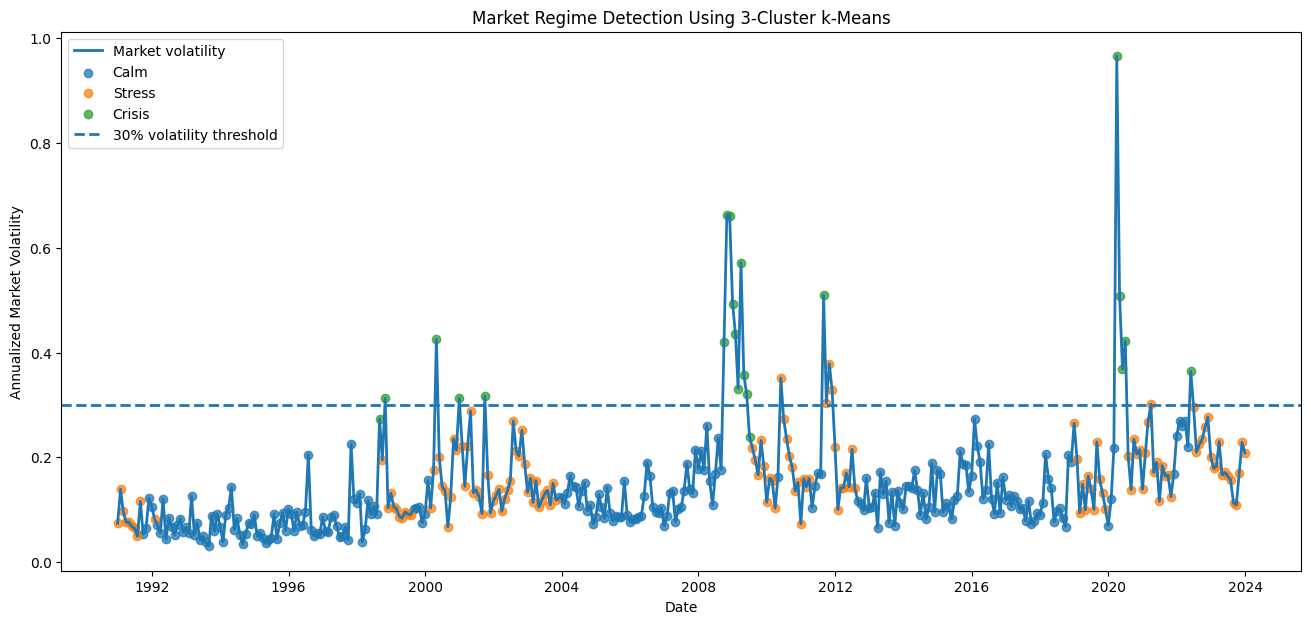

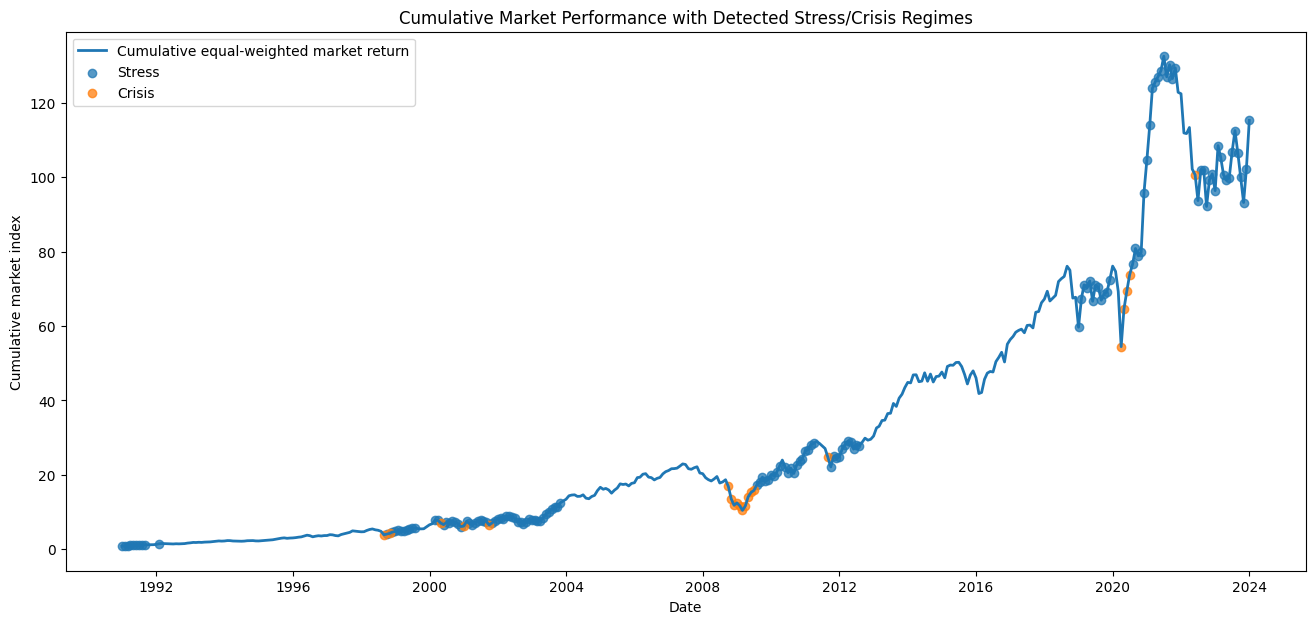


Saved: data/clean_monthly_panel_with_3regimes.csv

Latest date: 2023-12-31
Nowcast regime: Stress

Distance to each cluster centroid:
Stress: 0.667
Calm: 2.851
Crisis: 3.830


In [9]:
# ============================================================
# 3-Cluster Regime Detection: Calm / Stress / Crisis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ------------------------------------------------------------
# 1. Load clean monthly panel
# ------------------------------------------------------------

df = pd.read_csv("data/clean_monthly_panel.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "permno"])

# ------------------------------------------------------------
# 2. Build market-level monthly regime dataset
# ------------------------------------------------------------

market_monthly = (
    df.groupby("date")
    .agg(
        market_ret=("ret", "mean"),
        avg_stock_vol=("real_vol_ann", "mean"),
        median_stock_vol=("real_vol_ann", "median"),
        market_vol=("mkt_vol_ann", "first"),
        high_vol_regime=("high_vol_regime", "first"),
        n_stocks=("permno", "nunique")
    )
    .reset_index()
)

# Rolling realized market volatility based on equal-weighted market returns
market_monthly["rolling_market_vol_12m"] = (
    market_monthly["market_ret"]
    .rolling(12)
    .std()
    * np.sqrt(12)
)

# Rolling average absolute market return
market_monthly["rolling_abs_ret_12m"] = (
    market_monthly["market_ret"]
    .abs()
    .rolling(12)
    .mean()
)

# Market drawdown
market_monthly["cum_market"] = (1 + market_monthly["market_ret"]).cumprod()
market_monthly["running_max"] = market_monthly["cum_market"].cummax()
market_monthly["drawdown"] = (
    market_monthly["cum_market"] / market_monthly["running_max"] - 1
)

market_monthly = market_monthly.dropna().reset_index(drop=True)

# ------------------------------------------------------------
# 3. Choose regime features
# ------------------------------------------------------------

regime_features = [
    "market_vol",
    "avg_stock_vol",
    "rolling_market_vol_12m",
    "rolling_abs_ret_12m",
    "drawdown"
]

X = market_monthly[regime_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# 4. K-means clustering: k = 3
# ------------------------------------------------------------

kmeans = KMeans(n_clusters=3, random_state=42, n_init=50)
market_monthly["regime_cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = (
    market_monthly
    .groupby("regime_cluster")[regime_features + ["market_ret"]]
    .mean()
)

print("Cluster summary:")
print(cluster_summary)

# ------------------------------------------------------------
# 5. Label clusters economically: Calm / Stress / Crisis
# ------------------------------------------------------------

# Highest volatility cluster = Crisis
crisis_cluster = cluster_summary["market_vol"].idxmax()

# Lowest volatility cluster = Calm
calm_cluster = cluster_summary["market_vol"].idxmin()

# Remaining cluster = Stress
stress_cluster = list(
    set(cluster_summary.index)
    - set([crisis_cluster, calm_cluster])
)[0]

def label_regime(cluster):
    if cluster == calm_cluster:
        return "Calm"
    elif cluster == stress_cluster:
        return "Stress"
    else:
        return "Crisis"

market_monthly["regime_label"] = (
    market_monthly["regime_cluster"]
    .apply(label_regime)
)

# Numeric label for later modelling
regime_map = {
    "Calm": 0,
    "Stress": 1,
    "Crisis": 2
}

market_monthly["regime_numeric"] = (
    market_monthly["regime_label"]
    .map(regime_map)
)

# ------------------------------------------------------------
# 6. Evaluate cluster quality
# ------------------------------------------------------------

sil_score = silhouette_score(X_scaled, market_monthly["regime_cluster"])

print()
print(f"Silhouette score: {sil_score:.3f}")

print()
print("Regime counts:")
print(market_monthly["regime_label"].value_counts())

print()
print("Average characteristics by regime:")
print(
    market_monthly
    .groupby("regime_label")[regime_features + ["market_ret"]]
    .mean()
    .sort_values("market_vol")
)

# ------------------------------------------------------------
# 7. Main visualization: regime classification over time
# ------------------------------------------------------------

plt.figure(figsize=(16, 7))

plt.plot(
    market_monthly["date"],
    market_monthly["market_vol"],
    linewidth=2,
    label="Market volatility"
)

for regime in ["Calm", "Stress", "Crisis"]:
    subset = market_monthly[
        market_monthly["regime_label"] == regime
    ]
    
    plt.scatter(
        subset["date"],
        subset["market_vol"],
        label=regime,
        alpha=0.75
    )

plt.axhline(
    0.30,
    linestyle="--",
    linewidth=2,
    label="30% volatility threshold"
)

plt.title("Market Regime Detection Using 3-Cluster k-Means")
plt.xlabel("Date")
plt.ylabel("Annualized Market Volatility")
plt.legend()
plt.show()

# ------------------------------------------------------------
# 8. Optional second visualization: cumulative market with regimes
# ------------------------------------------------------------

plt.figure(figsize=(16, 7))

plt.plot(
    market_monthly["date"],
    market_monthly["cum_market"],
    linewidth=2,
    label="Cumulative equal-weighted market return"
)

for regime in ["Stress", "Crisis"]:
    subset = market_monthly[
        market_monthly["regime_label"] == regime
    ]
    
    plt.scatter(
        subset["date"],
        subset["cum_market"],
        label=regime,
        alpha=0.75
    )

plt.title("Cumulative Market Performance with Detected Stress/Crisis Regimes")
plt.xlabel("Date")
plt.ylabel("Cumulative market index")
plt.legend()
plt.show()

# ------------------------------------------------------------
# 9. Merge regime labels back into stock-level panel
# ------------------------------------------------------------

regime_data = market_monthly[
    ["date", "regime_cluster", "regime_label", "regime_numeric"]
].copy()

df_regime = df.merge(regime_data, on="date", how="left")

df_regime = df_regime.sort_values(["permno", "date"])

df_regime["regime_label_lag1"] = (
    df_regime
    .groupby("permno")["regime_label"]
    .shift(1)
)

df_regime["regime_numeric_lag1"] = (
    df_regime
    .groupby("permno")["regime_numeric"]
    .shift(1)
)

df_regime.to_csv(
    "data/clean_monthly_panel_with_3regimes.csv",
    index=False
)

print()
print("Saved: data/clean_monthly_panel_with_3regimes.csv")

# ------------------------------------------------------------
# 10. Nowcast latest available regime
# ------------------------------------------------------------

latest = market_monthly.iloc[-1:].copy()

latest_features = latest[regime_features]
latest_scaled = scaler.transform(latest_features)

latest_cluster = kmeans.predict(latest_scaled)[0]
latest_label = label_regime(latest_cluster)

print()
print("Latest date:", latest["date"].iloc[0].date())
print("Nowcast regime:", latest_label)

distances = kmeans.transform(latest_scaled)[0]

print()
print("Distance to each cluster centroid:")
for cluster_id, distance in enumerate(distances):
    label = label_regime(cluster_id)
    print(f"{label}: {distance:.3f}")

In [10]:
# ============================================================
# Model A1: Crisis Exit Rule
# Exit if previous month was classified as Crisis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load regime-enhanced data
# ------------------------------------------------------------

df = pd.read_csv("data/clean_monthly_panel_with_3regimes.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["permno", "date"])

# Create lagged regime and lagged high-volatility flag
df["regime_label_lag1"] = df.groupby("permno")["regime_label"].shift(1)
df["high_vol_regime_lag1"] = df.groupby("permno")["high_vol_regime"].shift(1)

# ------------------------------------------------------------
# 2. Helper function
# ------------------------------------------------------------

def run_low_vol_strategy_with_exit(df, exit_regimes, label, n_stocks=500):
    results = []

    for date, month_df in df.groupby("date"):

        available = month_df.dropna(
            subset=[
                "real_vol_ann_lag1",
                "regime_label_lag1",
                "high_vol_regime_lag1",
                "ret"
            ]
        ).copy()

        if len(available) < n_stocks:
            continue

        lagged_regime = available["regime_label_lag1"].iloc[0]
        lagged_high_vol = bool(available["high_vol_regime_lag1"].iloc[0])

        invested = lagged_regime not in exit_regimes

        if invested:
            selected = available.nsmallest(n_stocks, "real_vol_ann_lag1").copy()

            # Capital cost doubles if previous market volatility exceeded 30%
            capital_cost_rate = 0.30 if lagged_high_vol else 0.15

            selected["capital_cost"] = (
                capital_cost_rate * selected["real_vol_ann_lag1"] / 12
            )

            selected["net_return"] = selected["ret"] - selected["capital_cost"]

            avg_net_return = selected["net_return"].mean()
            avg_gross_return = selected["ret"].mean()
            avg_capital_cost = selected["capital_cost"].mean()
            avg_selected_vol = selected["real_vol_ann_lag1"].mean()

        else:
            avg_net_return = 0.0
            avg_gross_return = 0.0
            avg_capital_cost = 0.0
            avg_selected_vol = np.nan

        results.append({
            "date": date,
            "model": label,
            "avg_net_return": avg_net_return,
            "avg_gross_return": avg_gross_return,
            "avg_capital_cost": avg_capital_cost,
            "avg_selected_vol": avg_selected_vol,
            "lagged_regime": lagged_regime,
            "high_vol_regime": lagged_high_vol,
            "invested": invested
        })

    out = pd.DataFrame(results).sort_values("date")

    out["cumulative_net_return"] = (
        1 + out["avg_net_return"]
    ).cumprod()

    out["running_max"] = out["cumulative_net_return"].cummax()
    out["drawdown"] = (
        out["cumulative_net_return"] / out["running_max"] - 1
    )

    return out


# ------------------------------------------------------------
# 3. Run Model A1
# ------------------------------------------------------------

crisis_exit_monthly = run_low_vol_strategy_with_exit(
    df=df,
    exit_regimes=["Crisis"],
    label="Crisis Exit Rule"
)

crisis_exit_monthly.head()

,date,model,avg_net_return,avg_gross_return,avg_capital_cost,avg_selected_vol,lagged_regime,high_vol_regime,invested,cumulative_net_return,running_max,drawdown
0,1991-01-31,Crisis Exit Rule,0.020081,0.020498,0.000417,0.033322,Stress,False,True,1.020081,1.020081,0.0
1,1991-02-28,Crisis Exit Rule,0.071860,0.072312,0.000451,0.036117,Stress,False,True,1.093384,1.093384,0.0
2,1991-03-31,Crisis Exit Rule,0.036118,0.036558,0.000440,0.035240,Stress,False,True,1.132875,1.132875,0.0
3,1991-04-30,Crisis Exit Rule,0.019745,0.020146,0.000402,0.032123,Stress,False,True,1.155243,1.155243,0.0
4,1991-05-31,Crisis Exit Rule,0.019942,0.020358,0.000416,0.033312,Stress,False,True,1.178281,1.178281,0.0


In [11]:
# ============================================================
# Model A2: Early-Warning Exit Rule
# Exit if previous month was Stress OR Crisis
# ============================================================

early_warning_exit_monthly = run_low_vol_strategy_with_exit(
    df=df,
    exit_regimes=["Stress", "Crisis"],
    label="Early-Warning Exit Rule"
)

early_warning_exit_monthly.head()

,date,model,avg_net_return,avg_gross_return,avg_capital_cost,avg_selected_vol,lagged_regime,high_vol_regime,invested,cumulative_net_return,running_max,drawdown
0,1991-01-31,Early-Warning Exit Rule,0.0,0.0,0.0,NaN,Stress,False,False,1.0,1.0,0.0
1,1991-02-28,Early-Warning Exit Rule,0.0,0.0,0.0,NaN,Stress,False,False,1.0,1.0,0.0
2,1991-03-31,Early-Warning Exit Rule,0.0,0.0,0.0,NaN,Stress,False,False,1.0,1.0,0.0
3,1991-04-30,Early-Warning Exit Rule,0.0,0.0,0.0,NaN,Stress,False,False,1.0,1.0,0.0
4,1991-05-31,Early-Warning Exit Rule,0.0,0.0,0.0,NaN,Stress,False,False,1.0,1.0,0.0


                     Model Avg Monthly Net Return Avg Annual Net Return  \
0         Crisis Exit Rule                  1.03%                13.06%   
1  Early-Warning Exit Rule                  0.48%                 5.91%   

  Std Monthly Net Return Sharpe Ratio Total Cumulative Return Max Drawdown  \
0                  2.65%         1.34                   50.04      -23.13%   
1                  2.17%         0.77                    6.05      -33.94%   

  Best Month Best Month Return Worst Month Worst Month Return  \
0   Nov 2020             9.69%    Mar 2020            -15.97%   
1   Nov 2016             7.75%    Mar 2020            -15.97%   

  Normal Month Net Return Crisis Month Net Return % Months Invested  
0                   1.07%                   0.35%            94.70%  
1                   0.51%                   0.00%            59.60%  


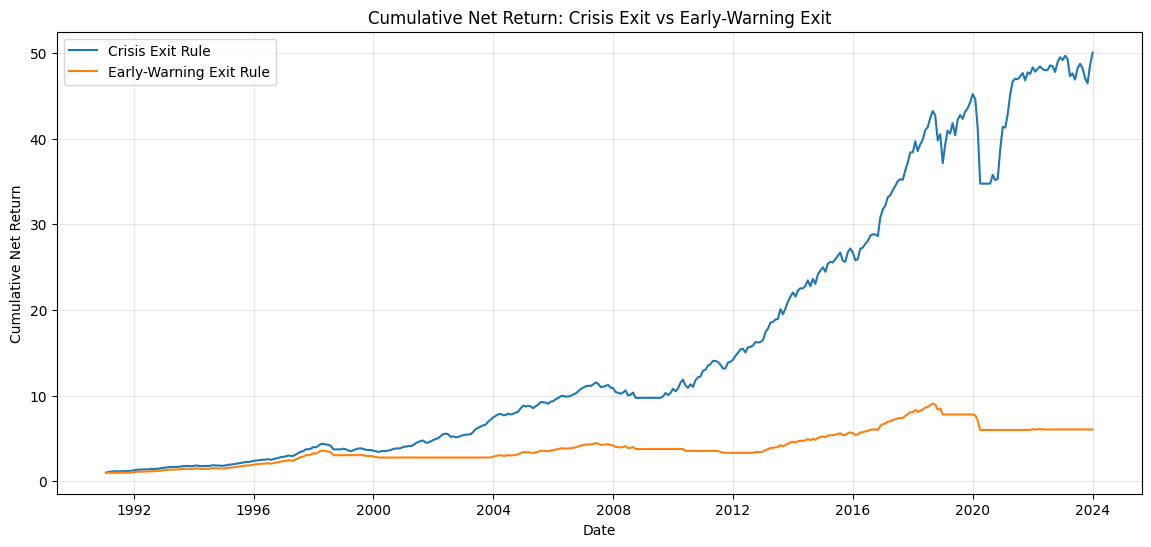

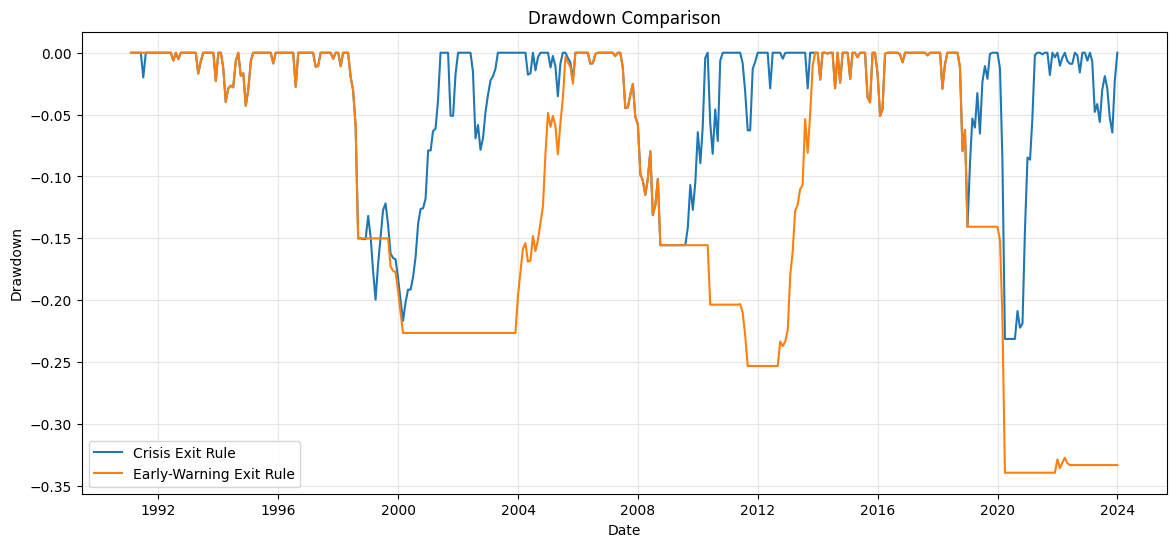

In [12]:
# ============================================================
# Compare Crisis Exit vs Early-Warning Exit
# ============================================================

def summarize_strategy(monthly_df, label):
    df_s = monthly_df.copy()

    avg_monthly = df_s["avg_net_return"].mean()
    avg_annual = (1 + avg_monthly) ** 12 - 1
    std_monthly = df_s["avg_net_return"].std()

    sharpe = (
        avg_monthly / std_monthly * np.sqrt(12)
        if std_monthly > 0 else np.nan
    )

    total_cumulative = df_s["cumulative_net_return"].iloc[-1]
    max_drawdown = df_s["drawdown"].min()

    best_idx = df_s["avg_net_return"].idxmax()
    worst_idx = df_s["avg_net_return"].idxmin()

    crisis_months = df_s[df_s["high_vol_regime"] == True]
    normal_months = df_s[df_s["high_vol_regime"] == False]

    return {
        "Model": label,
        "Avg Monthly Net Return": avg_monthly,
        "Avg Annual Net Return": avg_annual,
        "Std Monthly Net Return": std_monthly,
        "Sharpe Ratio": sharpe,
        "Total Cumulative Return": total_cumulative,
        "Max Drawdown": max_drawdown,
        "Best Month": df_s.loc[best_idx, "date"],
        "Best Month Return": df_s.loc[best_idx, "avg_net_return"],
        "Worst Month": df_s.loc[worst_idx, "date"],
        "Worst Month Return": df_s.loc[worst_idx, "avg_net_return"],
        "Normal Month Net Return": normal_months["avg_net_return"].mean(),
        "Crisis Month Net Return": crisis_months["avg_net_return"].mean(),
        "% Months Invested": df_s["invested"].mean()
    }


comparison = pd.DataFrame([
    summarize_strategy(crisis_exit_monthly, "Crisis Exit Rule"),
    summarize_strategy(early_warning_exit_monthly, "Early-Warning Exit Rule")
])

comparison_display = comparison.copy()

percent_cols = [
    "Avg Monthly Net Return",
    "Avg Annual Net Return",
    "Std Monthly Net Return",
    "Max Drawdown",
    "Best Month Return",
    "Worst Month Return",
    "Normal Month Net Return",
    "Crisis Month Net Return",
    "% Months Invested"
]

for col in percent_cols:
    comparison_display[col] = comparison_display[col].map(lambda x: f"{x:.2%}")

comparison_display["Sharpe Ratio"] = comparison_display["Sharpe Ratio"].map(lambda x: f"{x:.2f}")
comparison_display["Total Cumulative Return"] = comparison_display["Total Cumulative Return"].map(lambda x: f"{x:.2f}")
comparison_display["Best Month"] = comparison_display["Best Month"].dt.strftime("%b %Y")
comparison_display["Worst Month"] = comparison_display["Worst Month"].dt.strftime("%b %Y")

print(comparison_display)

# ------------------------------------------------------------
# Plot cumulative performance
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    crisis_exit_monthly["date"],
    crisis_exit_monthly["cumulative_net_return"],
    label="Crisis Exit Rule"
)

plt.plot(
    early_warning_exit_monthly["date"],
    early_warning_exit_monthly["cumulative_net_return"],
    label="Early-Warning Exit Rule"
)

plt.title("Cumulative Net Return: Crisis Exit vs Early-Warning Exit")
plt.xlabel("Date")
plt.ylabel("Cumulative Net Return")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Plot drawdowns
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    crisis_exit_monthly["date"],
    crisis_exit_monthly["drawdown"],
    label="Crisis Exit Rule"
)

plt.plot(
    early_warning_exit_monthly["date"],
    early_warning_exit_monthly["drawdown"],
    label="Early-Warning Exit Rule"
)

plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.3)
plt.show()